# Practical Session 02c &mdash; Gradient descent from scratch

**Companion to Lecture&nbsp;02.** In 02b we jumped straight to the bottom of the cost bowl with a
formula. That is perfect for modest problems, but the $O(d^3)$ solve becomes impractical for very
large models, needs all the data in memory, and does not exist for models beyond linear
regression. **Gradient descent** avoids all three problems: instead of jumping, it *walks*
downhill, one small step at a time &mdash; the workhorse that trains almost every modern model.

We implement it from scratch in NumPy, watch it roll to the bottom of the bowl from 02a, and meet
the two knobs that decide whether it gets there: the **learning rate** and **feature scaling**.

> ⭐ **Key idea.** Repeatedly step *against* the gradient of the cost:
> $\boldsymbol\theta \leftarrow \boldsymbol\theta - \eta\,\nabla J(\boldsymbol\theta)$. The
> gradient points uphill, so $-\nabla J$ points downhill; the step size $\eta$ (the *learning
> rate*) controls how far you move each step.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_regression_1d, make_regression_md

use_style("notes")
np.set_printoptions(precision=3, suppress=True)
print("ready")

ready


## 1. The gradient of the least-squares cost

With the design-matrix cost $J(\boldsymbol\theta) = \tfrac1n\lVert \mathbf{X}\boldsymbol\theta -
\mathbf{y}\rVert^2$, the gradient (the vector of partial derivatives, pointing in the direction of
steepest *increase*) is

$$\nabla J(\boldsymbol\theta) = \frac{2}{n}\,\mathbf{X}^{\!\top}(\mathbf{X}\boldsymbol\theta - \mathbf{y}).$$

It is just the design matrix transposed, times the residuals. One line of NumPy:

In [2]:
def mse(X, y, theta):
    return np.mean((X @ theta - y) ** 2)

def grad(X, y, theta):
    n = len(y)
    return (2 / n) * X.T @ (X @ theta - y)     # (2/n) * X^T * residuals

## 2. Batch gradient descent, from scratch

Start anywhere, compute the gradient on the **whole** training set, take a small step against it,
repeat. We record the cost each step so we can watch it fall. We standardize the feature first
(so the bowl is nicely shaped &mdash; Section&nbsp;4 explains why this matters).

In [3]:
x, y = make_regression_1d(n=60, seed=0)
xs = (x - x.mean()) / x.std()                  # standardized feature (mean 0, std 1)
X = np.column_stack([np.ones_like(xs), xs])    # design matrix [1, xs]

def gradient_descent(X, y, lr=0.1, n_iter=80, theta0=None):
    theta = np.zeros(X.shape[1]) if theta0 is None else theta0.astype(float).copy()
    losses, path = [], [theta.copy()]
    for _ in range(n_iter):
        theta = theta - lr * grad(X, y, theta)  # the one update rule
        losses.append(mse(X, y, theta))
        path.append(theta.copy())
    return theta, np.array(losses), np.array(path)

theta_gd, losses, path = gradient_descent(X, y, lr=0.3, n_iter=60)
theta_closed = np.linalg.lstsq(X, y, rcond=None)[0]   # the exact answer from 02b

print("gradient descent :", theta_gd)
print("closed form (02b):", theta_closed)
print("agree:", np.allclose(theta_gd, theta_closed, atol=1e-3))

gradient descent : [8.181 2.924]
closed form (02b): [8.181 2.924]
agree: True


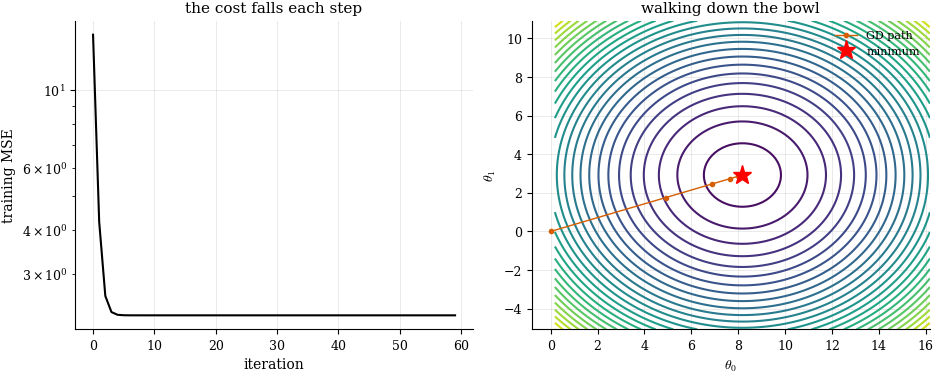

In [4]:
# watch it converge, and trace its path across the cost bowl (as in 02a)
t0 = np.linspace(theta_closed[0] - 8, theta_closed[0] + 8, 120)
t1 = np.linspace(theta_closed[1] - 8, theta_closed[1] + 8, 120)
T0, T1 = np.meshgrid(t0, t1)
J = np.array([[mse(X, y, np.array([a, b])) for a in t0] for b in t1])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.8))
a1.plot(losses); a1.set_xlabel("iteration"); a1.set_ylabel("training MSE")
a1.set_title("the cost falls each step"); a1.set_yscale("log"); a1.grid(alpha=0.3)
a2.contour(T0, T1, J, levels=25, cmap="viridis")
a2.plot(path[:, 0], path[:, 1], "o-", color="#D55E00", ms=3, lw=1, label="GD path")
a2.plot(*theta_closed, "r*", ms=14, label="minimum")
a2.set_xlabel(r"$\theta_0$"); a2.set_ylabel(r"$\theta_1$"); a2.set_title("walking down the bowl")
a2.legend(fontsize=8)
plt.show()

The loss drops smoothly to the closed-form minimum, and the path spirals into the bottom of the
bowl &mdash; gradient descent and the normal equations reach the *same* place, one by walking, one by
jumping.

## 3. The learning rate: the master knob

$\eta$ sets the step length. **Too small** and it crawls; **too large** and it overshoots the
minimum and can *diverge* (the cost blows up). There is a sweet spot in between.

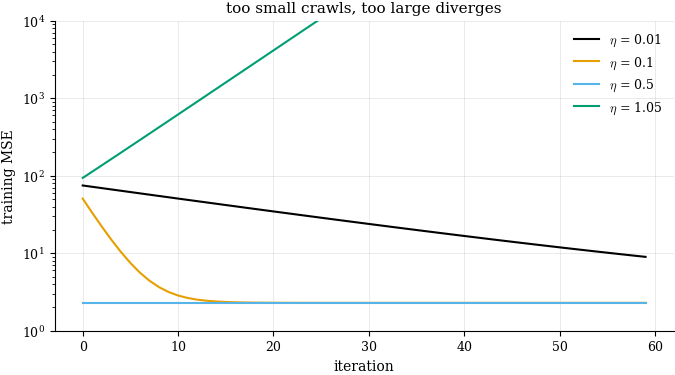

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 3.8))
for lr in [0.01, 0.1, 0.5, 1.05]:
    _, L, _ = gradient_descent(X, y, lr=lr, n_iter=60)
    ax.plot(L, label=f"$\\eta$ = {lr}")
ax.set_xlabel("iteration"); ax.set_ylabel("training MSE"); ax.set_yscale("log")
ax.set_title("too small crawls, too large diverges"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(1e0, 1e4)
plt.show()

> ⚠️ **Watch out.** With $\eta = 1.05$ the cost *increases* every step and races off to infinity
> &mdash; the classic sign of a learning rate past the stability limit. If your loss explodes or
> oscillates, the first thing to try is a **smaller** learning rate. (For least squares the
> stable range depends on the curvature of the bowl, which is exactly what feature scaling
> controls &mdash; next.)

## 4. Feature scaling shapes the bowl

Why did we standardize in Section&nbsp;2? Because when features live on **very different scales**,
the cost bowl becomes a long, thin *ravine*, and gradient descent zig-zags slowly down it.
Standardizing makes the bowl round, so the gradient points (almost) straight at the minimum. Here
are two features whose scales differ by 100&times;.

In [6]:
rng = np.random.default_rng(1)
n = 200
f1 = rng.normal(0, 1, n)            # feature on scale ~1
f2 = rng.normal(0, 8, n)           # feature on scale ~8
yraw = f1 + f2 + rng.normal(0, 1, n)

# center everything so there is no intercept to worry about; theta = (w1, w2)
Xraw = np.column_stack([f1, f2]) - np.column_stack([f1, f2]).mean(0)
yc = yraw - yraw.mean()
Xstd = Xraw / Xraw.std(0)           # standardized version

print("condition number of X^T X  --  raw:", f"{np.linalg.cond(Xraw.T @ Xraw):.0f}",
      " | standardized:", f"{np.linalg.cond(Xstd.T @ Xstd):.1f}")
print("(a large condition number = a long thin bowl = slow, zig-zagging gradient descent)")

condition number of X^T X  --  raw: 60  | standardized: 1.1
(a large condition number = a long thin bowl = slow, zig-zagging gradient descent)


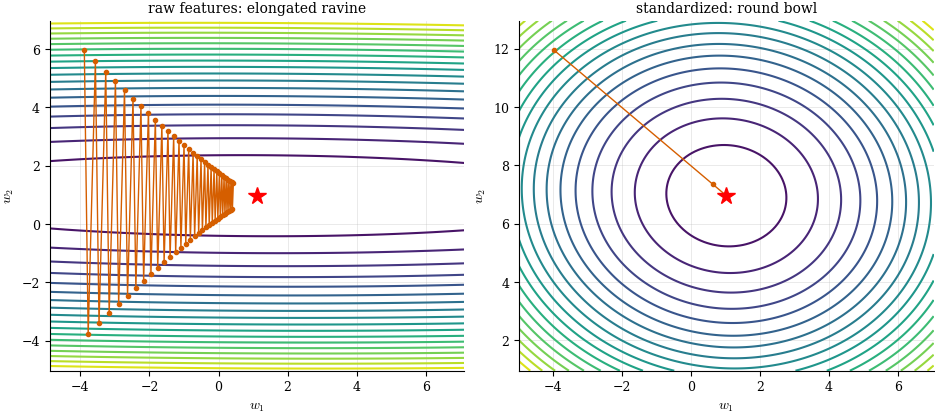

In [7]:
def stable_lr(Xd, frac):
    # largest safe step is 2 / (largest curvature of the bowl); take a fraction of it
    H = (2 / len(Xd)) * (Xd.T @ Xd)                 # Hessian of the MSE
    return frac * 2.0 / np.linalg.eigvalsh(H).max()

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.2))
for ax, (Xd, name, frac) in zip(axes, [(Xraw, "raw features: elongated ravine", 0.98),
                                       (Xstd, "standardized: round bowl", 0.5)]):
    opt = np.linalg.lstsq(Xd, yc, rcond=None)[0]                    # bottom of this bowl
    g0 = np.linspace(opt[0] - 6, opt[0] + 6, 140)
    g1 = np.linspace(opt[1] - 6, opt[1] + 6, 140)
    A, B = np.meshgrid(g0, g1)
    Z = np.array([[mse(Xd, yc, np.array([a, b])) for a in g0] for b in g1])
    ax.contour(A, B, Z, levels=20, cmap="viridis")
    _, _, p = gradient_descent(Xd, yc, lr=stable_lr(Xd, frac), n_iter=60,
                               theta0=opt + np.array([-5.0, 5.0]))
    ax.plot(p[:, 0], p[:, 1], "o-", color="#D55E00", ms=3, lw=1)
    ax.plot(*opt, "r*", ms=13)
    ax.set_xlabel(r"$w_1$"); ax.set_ylabel(r"$w_2$"); ax.set_title(name, fontsize=10)
plt.show()

> 💡 **Intuition.** On the raw features the contours are stretched into a canyon; the gradient
> points across the canyon rather than along it, so GD bounces from wall to wall and inches toward
> the minimum. Standardizing rescales the axes so the canyon becomes a round bowl and the very
> first step already aims at the bottom. **Always standardize features before gradient descent**
> (the closed form of 02b does not care, but every iterative method does).

## 5. Stochastic & mini-batch gradient descent

Batch GD uses *all* $n$ examples for every step &mdash; expensive when $n$ is huge. **Stochastic**
GD (SGD) uses **one** example per step; **mini-batch** GD uses a small random handful. Each step
is cheaper and the extra randomness often helps, at the price of a noisier path.

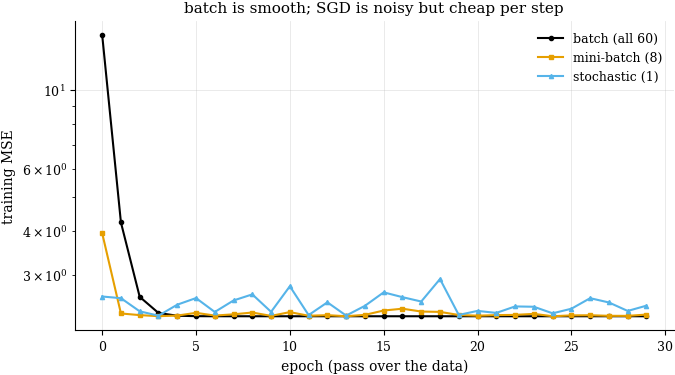

In [8]:
def sgd(X, y, lr=0.05, n_epochs=30, batch=1, seed=0):
    rng = np.random.default_rng(seed)
    theta = np.zeros(X.shape[1]); losses = []
    n = len(y)
    for _ in range(n_epochs):
        order = rng.permutation(n)
        for start in range(0, n, batch):
            idx = order[start:start + batch]
            theta = theta - lr * grad(X[idx], y[idx], theta)   # gradient on the mini-batch only
        losses.append(mse(X, y, theta))
    return theta, np.array(losses)

_, Lbatch, _ = gradient_descent(X, y, lr=0.3, n_iter=30)
_, Lmini = sgd(X, y, lr=0.1, n_epochs=30, batch=8)
_, Lsgd  = sgd(X, y, lr=0.05, n_epochs=30, batch=1)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(Lbatch, "o-", ms=3, label="batch (all 60)")
ax.plot(Lmini,  "s-", ms=3, label="mini-batch (8)")
ax.plot(Lsgd,   "^-", ms=3, label="stochastic (1)")
ax.set_xlabel("epoch (pass over the data)"); ax.set_ylabel("training MSE"); ax.set_yscale("log")
ax.set_title("batch is smooth; SGD is noisy but cheap per step"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.show()

> 🔬 **Going deeper.** Per *epoch* (one pass over the data), mini-batch and stochastic GD often
> make far more progress than batch GD, because they take many cheap steps instead of one big one.
> Their loss curves are jagged &mdash; each step follows a *noisy* estimate of the true gradient &mdash;
> but that noise also helps escape flat regions and, for big models, generalizes better. This is
> why **mini-batch SGD** (batch sizes like 32&ndash;256) trains essentially all deep networks.

## 6. Packaging it: a from-scratch estimator, checked against scikit-learn

Finally, wrap standardization + batch GD into a small `fit`/`predict` object &mdash; the same shape
as a scikit-learn estimator &mdash; and confirm it matches `LinearRegression` on multivariate data.

In [9]:
class LinearRegressionGD:
    def __init__(self, lr=0.1, n_iter=500):
        self.lr, self.n_iter = lr, n_iter
    def fit(self, X, y):
        self.mu_, self.sd_ = X.mean(0), X.std(0)          # standardize on TRAIN stats
        Z = np.column_stack([np.ones(len(X)), (X - self.mu_) / self.sd_])
        self.theta_, _, _ = gradient_descent(Z, y, lr=self.lr, n_iter=self.n_iter)
        return self
    def predict(self, X):
        Z = np.column_stack([np.ones(len(X)), (X - self.mu_) / self.sd_])
        return Z @ self.theta_

Xmd, ymd, w_true, b_true = make_regression_md(n=400, d=5, seed=2, noise=2.0)
ours = LinearRegressionGD(lr=0.3, n_iter=800).fit(Xmd, ymd)

from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(Xmd, ymd)
print("our GD predictions vs sklearn:  max |diff| =", np.max(np.abs(ours.predict(Xmd) - sk.predict(Xmd))))
print("our GD test-point prediction :", ours.predict(Xmd[:3]).round(3))
print("sklearn      prediction      :", sk.predict(Xmd[:3]).round(3))

our GD predictions vs sklearn:  max |diff| = 5.329070518200751e-15
our GD test-point prediction : [-4.348  2.108 -1.655]
sklearn      prediction      : [-4.348  2.108 -1.655]


Given enough iterations, the from-scratch gradient-descent model and scikit-learn's exact solver
make the **same predictions** &mdash; two roads to the bottom of the same convex bowl.

## Recap & exercises

**Recap.**
* Gradient descent repeats one rule: $\boldsymbol\theta \leftarrow \boldsymbol\theta -
  \eta\,\nabla J$, with $\nabla J = \tfrac{2}{n}\mathbf{X}^{\!\top}(\mathbf{X}\boldsymbol\theta -
  \mathbf{y})$. It reaches the same minimum as the closed form.
* The **learning rate** $\eta$ is the master knob: too small crawls, too large diverges.
* **Feature scaling** reshapes the cost bowl from a thin ravine into a round bowl &mdash; always
  standardize before any iterative solver.
* **Batch / mini-batch / stochastic** GD trade smoothness for cost-per-step; mini-batch SGD is the
  default for large models.
* A tidy from-scratch estimator matches scikit-learn's predictions.

**Exercises.**
1. In Section&nbsp;2, start GD from `theta0 = [10, -10]`. Does it still reach the minimum? How many
   iterations does it take?
2. Find the largest learning rate in Section&nbsp;3 that still converges (try 0.9, 0.99, 1.0). What
   happens right at the edge?
3. Remove the standardization in Section&nbsp;2 (fit on raw `x`). What learning rate do you now
   need to avoid divergence, and how many more iterations?
4. Add a **decaying** learning rate to `sgd` (e.g. `lr / (1 + 0.1*epoch)`). Does the stochastic
   loss curve get smoother near the end?
5. Time `LinearRegressionGD.fit` vs `np.linalg.lstsq` on `make_regression_md(n=5000, d=500)`. For
   which shapes would you prefer gradient descent over the closed form?

*Next:* **02d &mdash; evaluation & complexity**: how to *score* a regression honestly (MSE, RMSE, MAE,
$R^2$ from scratch), and how adding polynomial features turns a line into a curve &mdash; and into
overfitting.